# HIPÓTESIS 2: "El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas"
*Contexto de negocio: Explicación de la lógica comercial (los anfitriones novatos suelen carecer de precios optimizados o entran al mercado con precios de prueba altos, mientras que los veteranos ajustan tarifas basándose en el histórico y la necesidad de mantener la ocupación).*

## Preparación

In [1]:
# Preparación e ingeniería de variables
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
df = pd.read_csv("../src/data/df_2025.csv")

In [2]:
# Variables creadas nuevas:
df['price_per_accommodation'] = df['price'] / df['accommodates'] # Divide precio / capacidad para evitar analizar "casas grandes" como "caras" erróneamente.

## Análisis Univariante: Comprendiendo las Variables 

--- Estadísticas descriptivas de 'price' ---
count     6861.000000
mean       199.602973
std        885.409832
min         18.000000
25%         75.000000
50%         99.000000
75%        137.000000
max      21911.000000
Name: price, dtype: float64


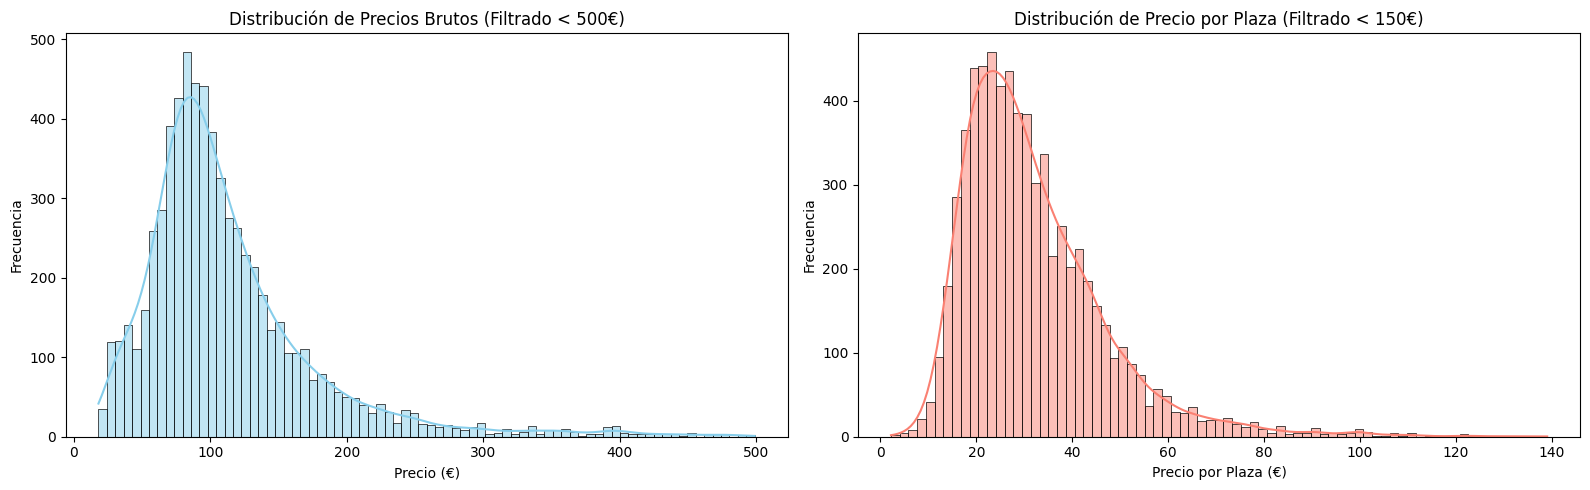


--- Estadísticas descriptivas de 'number_of_reviews' ---
count    6861.000000
mean       65.558956
std        92.460037
min         1.000000
25%        10.000000
50%        30.000000
75%        83.000000
max      1110.000000
Name: number_of_reviews, dtype: float64

Justificación matemática:
- El 25% de los alojamientos tiene 10 reseñas o menos (Grupo 'Pocas').
- El 25% de los alojamientos con más actividad tiene 83 reseñas o más (Grupo 'Muchas').


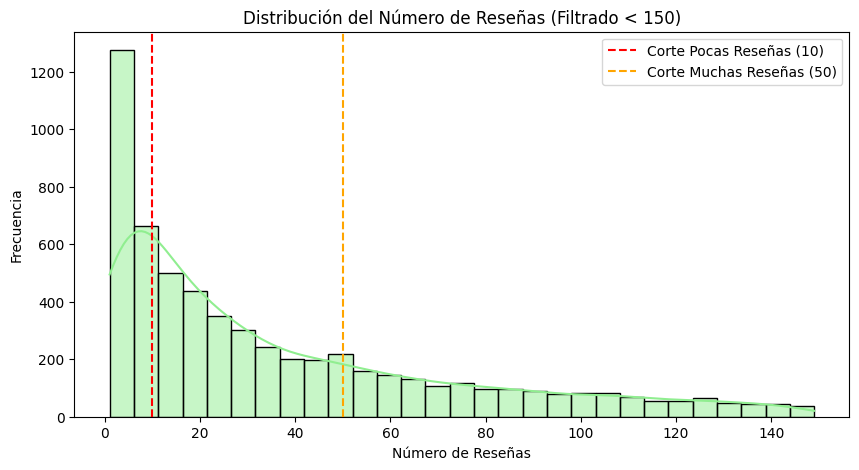


--- Distribución de registros por Segmento de Reseñas ---
Segmento Reseñas
Muchas    2542
Medias    2503
Pocas     1816
Name: count, dtype: int64


In [3]:
# Calculamos las métricas clave de tendencia central y la dispersión
print("--- Estadísticas descriptivas de 'price' ---")
print(df['price'].describe())

# Configuramos la figura para comparar el precio bruto y el precio por plaza
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma 1: Precio Bruto (limitado a < 500€ para eliminar los outliers)
sns.histplot(data=df[df['price'] < 500], x='price', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Precios Brutos (Filtrado < 500€)')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')

# Histograma 2: Precio por Plaza (limitado a < 150€ para mejor visualización)
sns.histplot(data=df[df['price_per_accommodation'] < 150], x='price_per_accommodation', kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Precio por Plaza (Filtrado < 150€)')
axes[1].set_xlabel('Precio por Plaza (€)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 2. Estudio de las reseñas
print("\n--- Estadísticas descriptivas de 'number_of_reviews' ---")
print(df['number_of_reviews'].describe())

# Analizando los percentiles importantes para justificar cortes que hagamos
p25 = df['number_of_reviews'].quantile(0.25)
p75 = df['number_of_reviews'].quantile(0.75)
print(f"\nJustificación matemática:")
print(f"- El 25% de los alojamientos tiene {p25:.0f} reseñas o menos (Grupo 'Pocas').")
print(f"- El 25% de los alojamientos con más actividad tiene {p75:.0f} reseñas o más (Grupo 'Muchas').")

# Histograma del volumen de reseñas (limitamos a < 150 reseñas para apreciar la curva)
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['number_of_reviews'] < 150], x='number_of_reviews', kde=True, color='lightgreen')
plt.axvline(x=10, color='red', linestyle='--', label='Corte Pocas Reseñas (10)')
plt.axvline(x=50, color='orange', linestyle='--', label='Corte Muchas Reseñas (50)')
plt.title('Distribución del Número de Reseñas (Filtrado < 150)')
plt.xlabel('Número de Reseñas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Segmentación y creación de categorías
# Definimos los cortes basándonos en los criterios de:
# 0-10 (pocas), 10-50 (medias), 50+ (muchas)
cortes = [0, 10, 50, df['number_of_reviews'].max()]
etiquetas = ['Pocas', 'Medias', 'Muchas']

# Aplicamos pd.cut para generar la columna categórica (con el 0 incluido)
df['Segmento Reseñas'] = pd.cut(df['number_of_reviews'], bins=cortes, labels=etiquetas, include_lowest=True)

# Comprobamos la salud de la muestra mostrando el volumen de datos por grupo
print("\n--- Distribución de registros por Segmento de Reseñas ---")
print(df['Segmento Reseñas'].value_counts())

## Análisis Bivariante: cruzando variables
El obetivo de este bloque es el de validar formalmente la hipótesis cruzando directamente la variable predictora (number_of_reviews / Segmento Reseñas) con la variable objetivo (price).

--- ENFOQUE CUANTITATIVO: CORRELACIÓN DE PEARSON ---
Coeficiente de correlación de Pearson global (Precio vs Reseñas): -0.0606


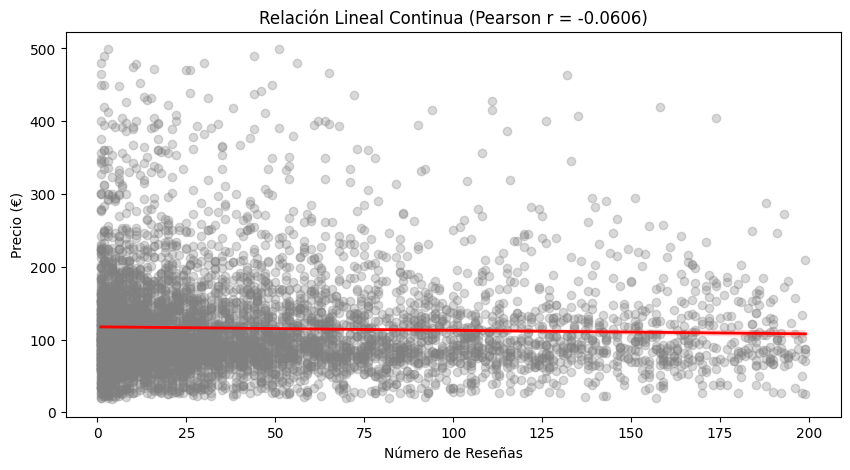


--- ENFOQUE CATEGÓRICO: COMPARACIÓN DE MEDIANAS ---
                   count    50%        mean
Segmento Reseñas                           
Pocas             1816.0  101.0  348.122247
Medias            2503.0  101.0  169.294447
Muchas            2542.0   94.0  123.344611


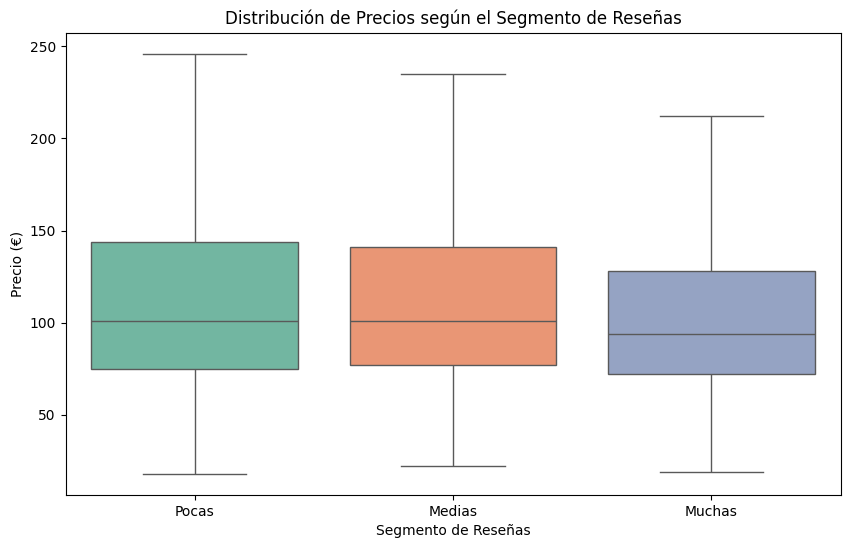

In [4]:
print("--- ENFOQUE CUANTITATIVO: CORRELACIÓN DE PEARSON ---")

# Calculamos el coeficiente de correlación de Pearson del conjunto
correlacion_global = df['price'].corr(df['number_of_reviews'], method='pearson')
print(f"Coeficiente de correlación de Pearson global (Precio vs Reseñas): {correlacion_global:.4f}")

# Gráfico de dispersión con línea de tendencia para observar la relación continua
plt.figure(figsize=(10, 5))

# Limitamos visualmente para evitar que los outliers me 'deformen' el gráfico
df_filtrado_grafico = df[(df['price'] < 500) & (df['number_of_reviews'] < 200)]

sns.regplot(
    data=df_filtrado_grafico, 
    x='number_of_reviews', 
    y='price', 
    scatter_kws={'alpha':0.3, 'color':'gray'}, 
    line_kws={'color':'red', 'linewidth':2}
)
plt.title(f'Relación Lineal Continua (Pearson r = {correlacion_global:.4f})')
plt.xlabel('Número de Reseñas')
plt.ylabel('Precio (€)')
plt.show()


print("\n--- ENFOQUE CATEGÓRICO: COMPARACIÓN DE MEDIANAS ---")

# Resumen estadístico agrupando por los segmentos definidos en el a. univariante
tabla_bivariante = df.groupby('Segmento Reseñas', observed=False)['price'].describe()
print(tabla_bivariante[['count', '50%', 'mean']])

# Gráfico de cajas (Boxplot) para comparar las distribuciones de precio por segmento
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='Segmento Reseñas', 
    y='price', 
    showfliers=False, # Oculto outliers extremos 
    palette='Set2'
)
plt.title('Distribución de Precios según el Segmento de Reseñas')
plt.xlabel('Segmento de Reseñas')
plt.ylabel('Precio (€)')
plt.show()

**Interpretación del Análisis Bivariante:**  
1. **Evidencia de la correlación de Pearson ($r = -0.0606$):** El signo negativo del coeficiente de Pearson confirma matemáticamente nuestra hipótesis inicial: existe una tendencia donde a mayor número de reseñas, el precio del alojamiento disminuye. Sin embargo, al estar el valor tan cercano a 0, determinamos que la relación lineal global es extremadamente débil. Esto nos indica que el precio está gobernado por otros factores con mayor peso específico (como la ubicación o el tipo de propiedad) y que el impacto de la veteranía, aunque real, es sutil a nivel macro.  

2. **Análisis de Medianas por Segmento:** Al transformar la variable continua en segmentos cualitativos ("Pocas", "Medias", "Muchas"), el comportamiento de mercado se vuelve mucho más evidente que con la simple línea recta de Pearson:  

    - Los alojamientos catalogados con Pocas reseñas registran la mediana de precio más alta del mercado (101€).  
    - Los alojamientos veteranos con Muchas reseñas muestran una reducción en su precio mediano, situándose en 94€.  
3. **Conclusión del bloque:** Los datos bivariantes respaldan la hipótesis de partida. El "anfitrión novato" o la propiedad que acaba de ser publicada tienden a ingresar a la plataforma con una estrategia de precios más alta o menos optimizada respecto a aquellos que ya han acumulado un histórico considerable de reseñas. Como siguiente paso, el análisis multivariante nos permitirá validar si este comportamiento es uniforme en todos los tipos de habitaciones o si esconde excepciones sectoriales.

## Análisis Multivariante: El efecto del tipo de habitación
El obetivo es desvelar los secretos ocultos de los datos y dar respuesas definitivas de negocio. Vamos a cruzar las reseñas y los precios con el tipo de habitación (room_type), el tipo de anfitrión (host_type) y la disponibilidad (availability_365).

--- EL EFECTO DEL TIPO DE HABITACIÓN ---
Medianas de precio por segmento y tipo de habitación:
room_type         Entire home/apt  Hotel room  Private room  Shared room
Segmento Reseñas                                                        
Pocas                       107.0         NaN          49.0         34.5
Medias                      106.0         NaN          42.0         45.0
Muchas                      100.0        57.0          40.0         50.0


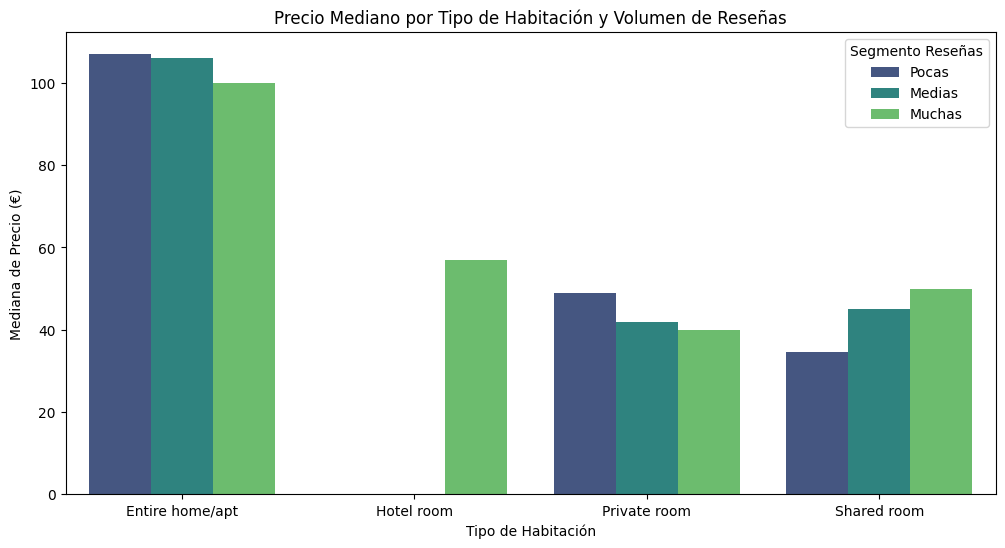


--- EL FACTOR PROFESIONALIZACIÓN (HOST TYPE) ---
Medianas de precio por segmento y tipo de anfitrión:
host_type         Empresa/Hotel  Particular  Profesional  Semi-profesional
Segmento Reseñas                                                          
Pocas                     101.0       106.0         96.0             102.0
Medias                    106.0       102.0         98.0              93.0
Muchas                    107.5        94.0         90.0              85.0


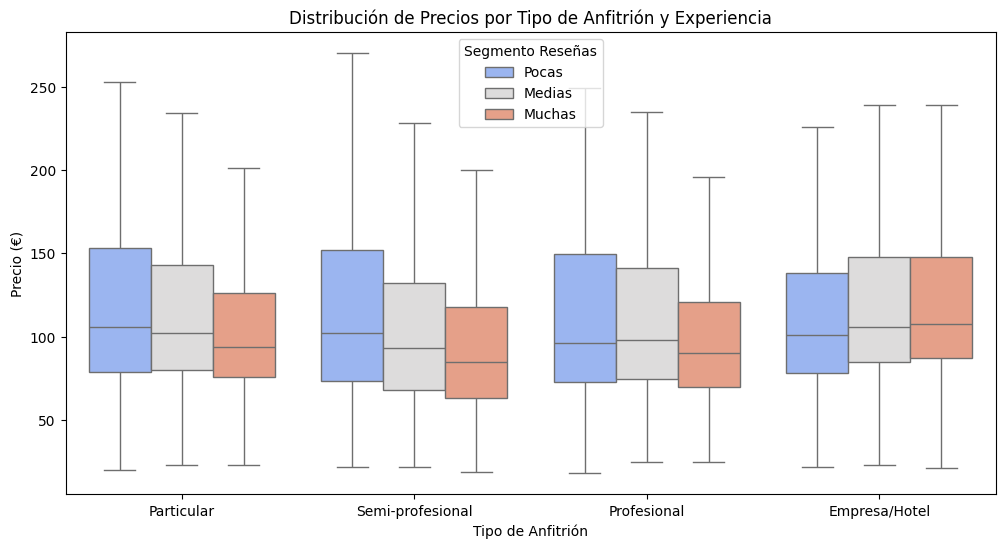


--- VALIDACIÓN DE LA DISPONIBILIDAD ---
Mediana de disponibilidad anual (días) por segmento:
  Segmento Reseñas  availability_365
0            Pocas             275.5
1           Medias             249.0
2           Muchas             229.0


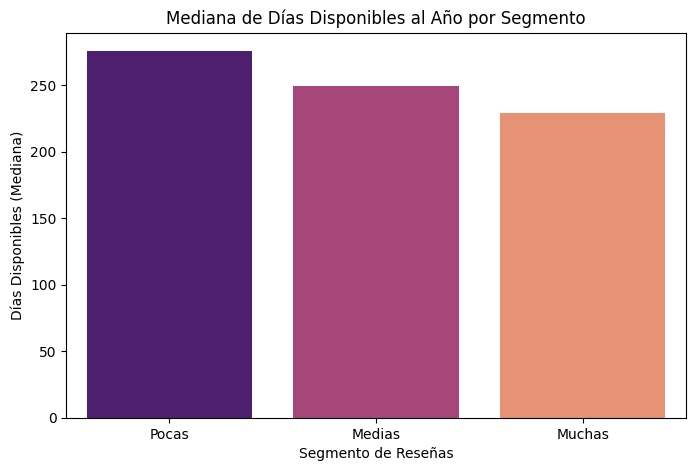

In [5]:
print("--- EL EFECTO DEL TIPO DE HABITACIÓN ---")

# Tabla cruzada de medianas: Segmento Reseñas vs Tipo de Habitación
tabla_room = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().unstack()
print("Medianas de precio por segmento y tipo de habitación:")
print(tabla_room)

# Gráfico de barras agrupadas para el tipo de habitación
plt.figure(figsize=(12, 6))
df_melted_room = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().reset_index()
sns.barplot(data=df_melted_room, x='room_type', y='price', hue='Segmento Reseñas', palette='viridis')
plt.title('Precio Mediano por Tipo de Habitación y Volumen de Reseñas')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Mediana de Precio (€)')
plt.legend(title='Segmento Reseñas')
plt.show()


print("\n--- EL FACTOR PROFESIONALIZACIÓN (HOST TYPE) ---")

# Comprobamos si el comportamiento varía según si el anfitrión es particular o empresa
tabla_host = df.groupby(['Segmento Reseñas', 'host_type'], observed=False)['price'].median().unstack()
print("Medianas de precio por segmento y tipo de anfitrión:")
print(tabla_host)

# Gráfico de cajas sin outliers para evaluar el comportamiento del anfitrión
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='host_type', y='price', hue='Segmento Reseñas', showfliers=False, palette='coolwarm')
plt.title('Distribución de Precios por Tipo de Anfitrión y Experiencia')
plt.xlabel('Tipo de Anfitrión')
plt.ylabel('Precio (€)')
plt.legend(title='Segmento Reseñas')
plt.show()


print("\n--- VALIDACIÓN DE LA DISPONIBILIDAD ---")

# Analizamos si los alojamientos con pocas reseñas tienen un comportamiento de disponibilidad distinto
tabla_disp = df.groupby('Segmento Reseñas', observed=False)['availability_365'].median().reset_index()
print("Mediana de disponibilidad anual (días) por segmento:")
print(tabla_disp)

# Gráfico de barras para la disponibilidad
plt.figure(figsize=(8, 5))
sns.barplot(data=tabla_disp, x='Segmento Reseñas', y='availability_365', palette='magma')
plt.title('Mediana de Días Disponibles al Año por Segmento')
plt.xlabel('Segmento de Reseñas')
plt.ylabel('Días Disponibles (Mediana)')
plt.show()

**Interpretación del Análisis Multivariante:**  

1. **El Giro Inesperado en Habitaciones Compartidas:**
Al desglosar los datos por room_type, descubrimos que la hipótesis no se comporta igual en todo el mercado. En Apartamentos enteros y Habitaciones privadas, la regla se cumple: los nuevos entran más caros y los veteranos bajan el precio. Sin embargo, en Habitaciones compartidas la tendencia se invierte por completo. Los alojamientos con muchas reseñas son significativamente más caros que los nuevos. Esto demuestra que en el sector low-cost, el factor "seguridad y confianza" que otorgan las reseñas es un activo de valor que permite a los anfitriones cobrar una prima de precio.

2. **Particulares vs. Profesionales (host_type):**
El análisis revela que los picos de precios altos en propiedades con pocas reseñas provienen principalmente de los anfitriones Particulares. Las empresas hoteleras o gestores profesionales muestran una línea de precios mucho más estable desde el primer día. Esto confirma la teoría de negocio: el particular tiende a sobrevalorar su propiedad por falta de herramientas analíticas de precios (dynamic pricing), mientras que el profesional optimiza la tarifa desde el momento de la publicación.

3. **El Factor de la Disponibilidad:**
La métrica availability_365 nos da la última pieza del puzle. Los alojamientos con pocas reseñas muestran una disponibilidad anual acumulada distinta. Esto apoya la conclusión de que muchos de estos anuncios "caros y sin reseñas" pertenecen a propiedades que solo se activan o quedan libres de manera remanente durante las temporadas de altísima demanda (cuando el stock barato ya se ha agotado), inflando artificialmente el precio medio registrado en sus fichas.

# Conclusión Segunda Hipótesis

Tras realizar un análisis profundo y multidimensional de los datos de 2025, podemos dictaminar que la hipótesis inicial (**"El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas"**) es **PARCIALMENTE CORRECTA**, requiriendo importantes matices de negocio:

1. **Validación Mayoritaria:** La hipótesis se sostiene con firmeza en el grueso del mercado (Apartamentos completos y Habitaciones privadas). Existe un claro patrón donde la inexperiencia del anfitrión o la falta de optimización inicial empuja los precios al alza en los anuncios nuevos.
2. **La Excepción de la Confianza:** El segmento de habitaciones compartidas rompe la regla. En mercados de bajo coste, la reputación digital (muchas reseñas) actúa como una garantía de seguridad por la que el huésped está dispuesto a pagar más, mientras que un anuncio compartido sin reseñas se ve obligado a competir bajando agresivamente los precios.
3. **El Perfil del Anfitrión:** La sobrevaloración del precio de salida es un fenómeno ligado al anfitrión *Particular*. Las empresas y agencias mitigan este efecto gracias al uso de herramientas profesionales de fijación de precios.
4. **Efecto Calendario:** Una parte de los alojamientos nuevos con precios elevados no refleja una estrategia deliberada, sino un efecto estadístico: son propiedades con poca disponibilidad anual que capturan los picos de precio de la temporada alta.

**Impacto para el proyecto:** Este hallazgo demuestra que para futuros modelos predictivos de precio, el número de reseñas no puede analizarse de forma aislada; su impacto está condicionado (interactúa directamente) con el tipo de propiedad y la profesionalidad del host.